Haptools simgenotype to generate Toy example
==================================================
This script requires:
    1. haptools
    2. A phased reference VCF (chr21 region from 1000G/HGDP data)
    3. The HapMap GRCh38 genetic map for chr21
    4. A sample_info .tsv mapping sample IDs -> population codes

Sample Types
---------
    Trivial          — 100% YRI (AFR) as an unadmixed control
    Two ancestries   — AFR + EUR admixture, 7 generations
    Three ancestries — AFR + EUR + AMR admixture, 7 generations

Outputs
-----
  python construct_toy_haptools.py

  Writes to ./toy_examples_haptools/

In [5]:
import subprocess
from pathlib import Path

# INPUTS 


REF_VCF = "1000G_chr21_pruned_renamed.vcf.gz"

# Directory containing HapMap GRCh38 .map files
# e.g.:
#   plink.chr21.GRCh38.map

MAP_DIR = "./"


SAMPLE_INFO = "1000genomes_sampleinfo_pruned.tsv"

#REGION = "chr21:10000000-15000000"
#REGION = "21:10000000-11500000"

REGION   = "21:1-32000000"
#48100155 is max


N_SAMPLES = 1


OUT_DIR = Path("toy_examples_haptools")

In [6]:
# Model file construction

def write_model(path: Path, lines: list[str]):
    path.write_text("\n".join(lines) + "\n")
    print(f"    model file : {path}")


def build_model_files(model_dir: Path, n_haplotypes: int):
    model_dir.mkdir(parents=True, exist_ok=True)

    # S1: Unadmixed control — 100% YRI for 1 generation ──
    write_model(model_dir / "S1_trivial.dat", [
        f"{n_haplotypes}\tAdmixed\tYRI",
        "1\t0\t1.0",
    ])
    
    write_model(model_dir / "S1_trivial.dat", [
    f"{n_haplotypes}\tAdmixed\tYRI\tIBS",
    "1\t0\t1.0\t0.0",
    ])

    # S2: Two ancestries — AFR + EUR, 7 generations ──
    # Generation 1: 80% YRI (AFR), 20% IBS (EUR).
    # Generations 2-7: purely admixed (draws from admixed pool only).
    write_model(model_dir / "S2_two_ancestries.dat", [
        f"{n_haplotypes}\tAdmixed\tYRI\tIBS",
        "1\t0\t0.8\t0.2",
        *[f"{g}\t1.0\t0\t0" for g in range(2, 8)],
    ])

    # S3: Three ancestries — AFR + EUR + AMR, 7 generations ──
    # Generation 1: 40% YRI (AFR), 40% IBS (EUR), 20% PEL
    # Generations 2-7: purely admixed.
    write_model(model_dir / "S3_three_ancestries.dat", [
        f"{n_haplotypes}\tAdmixed\tYRI\tIBS\tPEL",
        "1\t0\t0.4\t0.4\t0.2",
        *[f"{g}\t1.0\t0\t0\t0" for g in range(2, 8)],
    ])




In [7]:
# Run haptools simgenotype
def run_simgenotype(scenario_name: str, model_file: Path, out_prefix: Path):
    """
    Run haptools simgenotype for one scenario.

    Outputs:
      <out_prefix>.vcf.gz   — simulated phased genotypes
      <out_prefix>.bp       — ground-truth ancestry breakpoints
    """
    # haptools expects --out argument to be .vcf.gz path
    out_vcf = out_prefix.parent / (out_prefix.name + ".vcf.gz")

    cmd = [
        "haptools", "simgenotype",
        "--model",       str(model_file),
        "--mapdir",      MAP_DIR,
        "--ref_vcf",     REF_VCF,
        "--sample_info", SAMPLE_INFO,
        "--region",      REGION,
        "--out",         str(out_vcf),
    ]

    print(f"\n  Running {scenario_name}...")
    print(f"    cmd: {' '.join(cmd)}")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"  ERROR in {scenario_name}:")
        print(result.stderr)
    else:
        bp_file = out_prefix.parent / (out_prefix.name + ".bp")
        print(f"    genotypes   → {out_vcf}")
        print(f"    breakpoints → {bp_file}")
        if result.stderr:
            for line in result.stderr.strip().splitlines()[-5:]:
                print(f"    [log] {line}")

In [8]:
# Parse breakpoints into a summary
def summarize_breakpoints(bp_file: Path):
    if not bp_file.exists():
        print(f"  [skip] {bp_file} not found")
        return

    print(f"\n  Breakpoints summary: {bp_file.name}")
    samples_seen = set()
    n_segments = 0
    pop_counts: dict = {}
    current_sample = None

    with open(bp_file) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("\t")
            if len(parts) == 1:
                current_sample = parts[0].rsplit("_", 1)[0]
                samples_seen.add(current_sample)
            elif len(parts) == 4:
                pop = parts[0]
                n_segments += 1
                pop_counts[pop] = pop_counts.get(pop, 0) + 1

    print(f"    individuals        : {len(samples_seen)}")
    print(f"    total segments     : {n_segments}")
    print(f"    ancestry seg counts: {pop_counts}")


if __name__ == "__main__":

    n_haplotypes = N_SAMPLES * 2  # diploid individuals

    OUT_DIR.mkdir(exist_ok=True)
    model_dir = OUT_DIR / "models"

    print("\nStep 1: Writing model files...")
    build_model_files(model_dir, n_haplotypes)

    print("\nStep 2: Running haptools simgenotype for each scenario...")

    scenarios = [
        ("S1_trivial",          model_dir / "S1_trivial.dat"),
        ("S2_two_ancestries",   model_dir / "S2_two_ancestries.dat"),
        ("S3_three_ancestries", model_dir / "S3_three_ancestries.dat"),
    ]

    for name, model_file in scenarios:
        out_prefix = OUT_DIR / name
        run_simgenotype(name, model_file, out_prefix)

    print("\nStep 3: Breakpoint summaries (ground truth inspection)...")
    for name, _ in scenarios:
        bp_file = OUT_DIR / (name + ".bp")
        summarize_breakpoints(bp_file)


Step 1: Writing model files...
    model file : toy_examples_haptools/models/S1_trivial.dat
    model file : toy_examples_haptools/models/S1_trivial.dat
    model file : toy_examples_haptools/models/S2_two_ancestries.dat
    model file : toy_examples_haptools/models/S3_three_ancestries.dat

Step 2: Running haptools simgenotype for each scenario...

  Running S1_trivial...
    cmd: haptools simgenotype --model toy_examples_haptools/models/S1_trivial.dat --mapdir ./ --ref_vcf 1000G_chr21_pruned_renamed.vcf.gz --sample_info 1000genomes_sampleinfo_pruned.tsv --region 21:1-32000000 --out toy_examples_haptools/S1_trivial.vcf.gz
    genotypes   → toy_examples_haptools/S1_trivial.vcf.gz
    breakpoints → toy_examples_haptools/S1_trivial.bp
    [log] [ WARNING] The max_variants parameter was not specified. We have no choice but to append to an ever-growing array, which can lead to memory overuse! (genotypes.py:165)
    [log] [    INFO] Loading genotypes from 2504 samples (genotypes.py:287)
   

### Running against FLARE

In [9]:
import pandas as pd

panel = pd.read_csv("1000genomes_sampleinfo_pruned.tsv", sep="\t", header=None, names=["sample", "pop"])

subset = (panel[panel["pop"].isin(["YRI", "IBS", "PEL"])]
          .groupby("pop")
          .head(10))

subset.to_csv("1000genomes_sampleinfo_subset.tsv", sep="\t", header=False, index=False)
print(subset["pop"].value_counts())

subset["sample"].to_csv("samples_subset.txt", index=False, header=False)

IBS    10
PEL    10
YRI    10
Name: pop, dtype: int64


In [1]:
"""
run_flare.py
Runs FLARE local ancestry inference on each toy example scenario.
Outputs go to flare_output/
"""

import subprocess
from pathlib import Path


FLARE_JAR    = "flare.jar"   
REF_VCF = "1000G_chr21_subset.vcf.gz"
REF_MAP = "1000genomes_sampleinfo_subset.tsv"
# REF_VCF      = "1000G_chr21_pruned_renamed.vcf.gz"
# REF_MAP      = "1000genomes_sampleinfo_subset.tsv"  # 2-col: sample_id  population
# change the map to have fewer
CHROM        = "21"
OUT_DIR      = Path("flare_output")

TOY_DIR      = Path("toy_examples_haptools")
SCENARIOS    = ["S1_trivial", "S2_two_ancestries", "S3_three_ancestries"]


def run_flare(scenario: str):
    target_vcf = TOY_DIR / f"{scenario}.vcf.gz"
    out_prefix = OUT_DIR / scenario / scenario

    out_prefix.parent.mkdir(parents=True, exist_ok=True)


    cmd = [
    "java", "-Xmx8g", "-jar", FLARE_JAR,
    f"ref={REF_VCF}",
    f"ref-panel={REF_MAP}",
    f"gt={target_vcf}",
    f"map=plink.chr21.GRCh38_renamed.map",
    #f"chrom={CHROM}",          
    f"out={out_prefix}",
    "em=true",
    #"em-its=5",                
    "min-mac=1",
    "nthreads=4",
    ]
    
    print(f"\nRunning FLARE on {scenario}...")
    print(f"  cmd: {' '.join(cmd)}")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"  ERROR:\n{result.stderr}")
    else:
        print(f"  Output → {out_prefix}.anc.vcf.gz")
        if result.stderr:
            for line in result.stderr.strip().splitlines()[-5:]:
                print(f"  [log] {line}")


if __name__ == "__main__":
    OUT_DIR.mkdir(exist_ok=True)
    for scenario in SCENARIOS:
        run_flare(scenario)


Running FLARE on S1_trivial...
  cmd: java -Xmx8g -jar flare.jar ref=1000G_chr21_subset.vcf.gz ref-panel=1000genomes_sampleinfo_subset.tsv gt=toy_examples_haptools/S1_trivial.vcf.gz map=plink.chr21.GRCh38_renamed.map out=flare_output/S1_trivial/S1_trivial em=true min-mac=1 nthreads=4
  Output → flare_output/S1_trivial/S1_trivial.anc.vcf.gz

Running FLARE on S2_two_ancestries...
  cmd: java -Xmx8g -jar flare.jar ref=1000G_chr21_subset.vcf.gz ref-panel=1000genomes_sampleinfo_subset.tsv gt=toy_examples_haptools/S2_two_ancestries.vcf.gz map=plink.chr21.GRCh38_renamed.map out=flare_output/S2_two_ancestries/S2_two_ancestries em=true min-mac=1 nthreads=4
  Output → flare_output/S2_two_ancestries/S2_two_ancestries.anc.vcf.gz

Running FLARE on S3_three_ancestries...
  cmd: java -Xmx8g -jar flare.jar ref=1000G_chr21_subset.vcf.gz ref-panel=1000genomes_sampleinfo_subset.tsv gt=toy_examples_haptools/S3_three_ancestries.vcf.gz map=plink.chr21.GRCh38_renamed.map out=flare_output/S3_three_ancestries

## Running script to evaluate accuracy of Flare Outputs

In [15]:
! python evaluate_flare.py


Scenario: S1_trivial
[W::vcf_parse_info] INFO 'AC' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'AN' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'NS' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'DP' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'EAS_AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'AMR_AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'AFR_AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'EUR_AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'SAS_AF' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'AA' is not defined in the header, assuming Type=String
[W::vcf_parse_info] INFO 'VT' is not defined in the header, assumin

## Running script to evaluate accuracy of HaploHMM tool outputs

In [6]:
! python evaluate_haplohmm.py

Loading haploHMM calls from: haploHMM_output/toy_example_ancestry_haplotypes.txt
  6344 SNPs, 12 haplotype columns

Scenario: S1_trivial

  S1_trivial_1
    hap1: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%
    hap2: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%

  S1_trivial_2
    hap1: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%
    hap2: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%

Scenario: S2_two_ancestries

  S2_two_ancestries_1
    hap1: 6333/6344 = 99.8%
      YRI: 2007/2007 = 100.0%
      IBS: 4326/4337 = 99.7%  [misclassified as: {'YRI': 11}]
    hap2: 4717/6344 = 74.4%
      YRI: 1704/3331 = 51.2%  [misclassified as: {'IBS': 1627}]
      IBS: 3013/3013 = 100.0%

  S2_two_ancestries_2
    hap1: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%
    hap2: 6344/6344 = 100.0%
      YRI: 6344/6344 = 100.0%

Scenario: S3_three_ancestries

  S3_three_ancestries_1
    hap1: 1682/6344 = 26.5%
      YRI: 595/617 = 96.4%  [misclassified as: {'IBS': 22}]
      IBS: 1087/

### Generating plots for accuracy comparison

Saved: tool_comparison.png


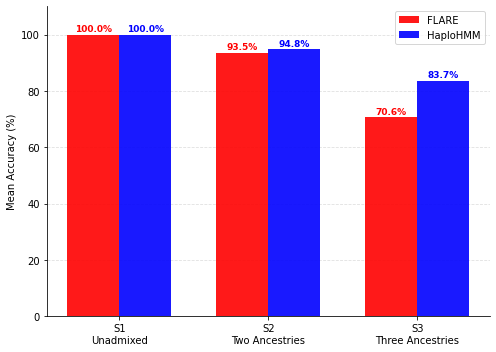

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data: (correct, total) per tool / scenario / sample / hap ────────────────
data = {
    "S1\nUnadmixed": {
        "FLARE":     [(6344,6344),(6344,6344),(6344,6344),(6344,6344)],
        "HaploHMM":  [(6222,6222),(6222,6222),(6222,6222),(6222,6222)],
    },
    "S2\nTwo Ancestries": {
        "FLARE":     [(6333,6344),(4717,6344),(6344,6344),(6344,6344)],
        "HaploHMM":  [(6182,6222),(4958,6222),(6222,6222),(6222,6222)],
    },
    "S3\nThree Ancestries": {
        "FLARE":     [(1682,6344),(6147,6344),(4708,6344),(5371,6344)],
        "HaploHMM":  [(5152,6222),(6011,6222),(4726,6222),(4939,6222)],
    },
}

labels = ["S1 h1","S1 h2","S1 h1","S1 h2",
          "S2 h1","S2 h2","S2 h1","S2 h2",
          "S3 h1","S3 h2","S3 h1","S3 h2"]

# Aggregate per scenario: mean accuracy across all haps
scenarios = list(data.keys())
flare_acc  = [np.mean([c/t*100 for c,t in data[s]["FLARE"]])    for s in scenarios]
haplo_acc  = [np.mean([c/t*100 for c,t in data[s]["HaploHMM"]]) for s in scenarios]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
#fig.suptitle("FLARE vs HaploHMM — Local Ancestry Accuracy", fontsize=14, fontweight="bold")

FLARE_COL = "red"
HAPLO_COL = "blue"

x = np.arange(len(scenarios))
w = 0.35
ax.bar(x - w/2, flare_acc, w, label="FLARE",    color=FLARE_COL, alpha=0.9)
ax.bar(x + w/2, haplo_acc, w, label="HaploHMM", color=HAPLO_COL, alpha=0.9)

for i, (f, h) in enumerate(zip(flare_acc, haplo_acc)):
    ax.text(i - w/2, f + 0.5, f"{f:.1f}%", ha="center", va="bottom", fontsize=9, color=FLARE_COL, fontweight="bold")
    ax.text(i + w/2, h + 0.5, f"{h:.1f}%", ha="center", va="bottom", fontsize=9, color=HAPLO_COL, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("Mean Accuracy (%)")
ax.set_ylim(0, 110)
ax.legend()
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("tool_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: tool_comparison.png")